##  Phase 1 – Problem Understanding & Dataset Analysis

### Industrial Context
Steel plates manufactured by Tata Steel undergo continuous rolling and cooling processes
that introduce **micro-level surface cracks** — hairline fractures typically 0.1–2mm wide
and invisible to the naked eye at production speed. If undetected before shipment, these
cracks cause catastrophic failures in end-use applications (automotive frames, bridges,
pressure vessels).

**Why manual inspection fails:**
- Lines run at 10–20 m/s; a human cannot scan 1600px-wide images in real time
- Cracks have low contrast against mill-scale surface noise (similar textures)
- Class imbalance: ~70% of plates have no defect → humans develop confirmation bias

**Our solution:** A two-stage deep learning pipeline —
- **Stage 1 (ResNet):** patch-wise crack/no-crack classifier → plate-level heatmap
- **Stage 2 (U-Net):** pixel-level segmentation for precise crack boundary localization
- **XAI (Grad-CAM):** explainability layer for production engineer trust

### Dataset: Severstal Steel Defect Detection (Kaggle)
- ~12,600 training images, resolution 256×1600px (grayscale converted to 3-ch)
- 4 defect classes encoded as RLE masks; Class 1 = surface cracks (our focus)
- ~6% of pixels are defective; severe class imbalance at patch level

### Evaluation Metrics
| Task | Metric | Justification |
|------|--------|---------------|
| Patch classification | **F1 / Precision / Recall** | Imbalanced classes; raw accuracy misleads |
| Plate-level decision | **ROC-AUC** | Threshold-independent; suits QC go/no-go |
| Segmentation | **Dice coefficient, IoU** | Overlap-based; standard for medical/industrial seg |
| Segmentation | **Pixel-wise F1** | Handles severe foreground sparsity |

In [ ]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────────
!pip install -q albumentations kaggle

from google.colab import drive
import os, glob

drive.mount("/content/drive")
# TEAMMATES: Before running this cell —
#   1. Open this link: https://drive.google.com/drive/folders/1K9cyi1K5AOyJXfJz6rElg3sgX7FYxexM
#   2. Click "Add shortcut to Drive" → My Drive (root)
#   3. Then run this cell
matches = glob.glob(
    "/content/drive/MyDrive/**/severstal-steel-defect-detection.zip",
    recursive=True
)
if not matches:
    raise FileNotFoundError(
        "Zip not found! Add the shared folder shortcut to your Drive first.\n"
        "Link: https://drive.google.com/drive/folders/1K9cyi1K5AOyJXfJz6rElg3sgX7FYxexM"
    )

os.makedirs("/content/data/raw/severstal", exist_ok=True)
!unzip -q "{matches[0]}" -d /content/data/raw/severstal/
print("Dataset ready.")

Mounted at /content/drive
Dataset ready.


In [ ]:
# ── Cell 2: Config + Plate-level train/val/test split ─────────────────────────
import pandas as pd, numpy as np, json, glob
from sklearn.model_selection import train_test_split

IMAGE_DIR = glob.glob("/content/data/raw/severstal/**/train_images", recursive=True)[0]
TRAIN_CSV = glob.glob("/content/data/raw/severstal/**/train.csv",    recursive=True)[0]

cfg = {
    "image_dir": IMAGE_DIR,
    "train_csv": TRAIN_CSV,
    "img_h": 256, "img_w": 1600,
    "patch_size": 256, "patch_stride": 128,
    "crack_class_id": 1,
    "val_frac": 0.15, "test_frac": 0.10, "seed": 42,
}

# Read CSV — Severstal has headers: ImageId, ClassId, EncodedPixels
df = pd.read_csv(cfg["train_csv"])
print("Columns found:", df.columns.tolist())
print("Sample rows:\n", df.head(3))

# Rename columns robustly regardless of capitalisation
df.columns = [c.strip() for c in df.columns]
col_map = {}
for c in df.columns:
    cl = c.lower()
    if "image" in cl:   col_map[c] = "ImageId"
    elif "class" in cl: col_map[c] = "ClassId"
    elif "encoded" in cl or "pixel" in cl: col_map[c] = "EncodedPixels"
df.rename(columns=col_map, inplace=True)

# Convert ClassId to int safely
df["ClassId"] = pd.to_numeric(df["ClassId"], errors="coerce")
df = df.dropna(subset=["ClassId"])
df["ClassId"] = df["ClassId"].astype(int)

# All unique plate IDs (from image filenames in the folder)
import os
all_ids   = sorted(os.listdir(IMAGE_DIR))
has_crack = set(
    df[(df["ClassId"] == cfg["crack_class_id"]) & (df["EncodedPixels"].notna())]["ImageId"]
)

# Split by plate ID
train_ids, temp    = train_test_split(all_ids, test_size=cfg["val_frac"]+cfg["test_frac"],
                                      random_state=cfg["seed"])
val_ids,  test_ids = train_test_split(temp,
                                      test_size=cfg["test_frac"]/(cfg["val_frac"]+cfg["test_frac"]),
                                      random_state=cfg["seed"])

json.dump({"train": train_ids, "val": val_ids, "test": test_ids},
          open("/content/split_indices.json", "w"))

print(f"\nTotal plates  : {len(all_ids)}")
print(f"  Train : {len(train_ids)}  |  Val : {len(val_ids)}  |  Test : {len(test_ids)}")
print(f"  Cracked plates : {len(has_crack)} / {len(all_ids)}")
print(f"\nColumns after fix: {df.columns.tolist()}")

Columns found: ['ImageId', 'ClassId', 'EncodedPixels']
Sample rows:
          ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...

Total plates  : 12568
  Train : 9426  |  Val : 1885  |  Test : 1257
  Cracked plates : 897 / 12568

Columns after fix: ['ImageId', 'ClassId', 'EncodedPixels']


In [ ]:
# ── Cell 3: Dataset classes + DataLoader factory ───────────────────────────────
import cv2, torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def decode_rle(rle, h=256, w=1600):
    mask = np.zeros(h * w, dtype=np.uint8)
    if pd.isna(rle): return mask.reshape(h, w, order="F")
    s = list(map(int, str(rle).split()))
    for start, length in zip(s[0::2], s[1::2]):
        mask[start-1 : start-1+length] = 1
    return mask.reshape(h, w, order="F")

def get_transforms(split):
    base = [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()]
    if split != "train": return A.Compose(base)
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5),
        *base
    ])

# Separate seg transforms — NO ToTensorV2, we handle it manually
def get_seg_transforms(split):
    base = [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))]
    if split != "train": return A.Compose(base)
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5),
        *base
    ])

class SteelPatchDataset(Dataset):
    """Stage 1: overlapping patches → crack / clean labels."""
    def __init__(self, image_ids, df, cfg, split="train"):
        self.df, self.cfg, self.transform = df, cfg, get_transforms(split)
        ps, st = cfg["patch_size"], cfg["patch_stride"]
        H, W   = cfg["img_h"], cfg["img_w"]
        self.patches = [(i, r, c) for i in image_ids
                        for r in range(0, H-ps+1, st)
                        for c in range(0, W-ps+1, st)]

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        img_id, r, c = self.patches[idx]
        ps = self.cfg["patch_size"]
        img = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
        crack_row = self.df[(self.df["ImageId"]==img_id) & (self.df["ClassId"]==1)]
        rle  = crack_row.iloc[0]["EncodedPixels"] if not crack_row.empty else np.nan
        mask = decode_rle(rle)
        patch_img, patch_mask = img[r:r+ps, c:c+ps], mask[r:r+ps, c:c+ps]
        label = 1 if patch_mask.sum() > 0 else 0
        out = self.transform(image=patch_img, mask=patch_mask)
        return out["image"], torch.tensor(label, dtype=torch.long)

class SteelSegDataset(Dataset):
    """Stage 2: full-plate tiles → image + binary crack mask pairs."""
    def __init__(self, image_ids, df, cfg, split="train", tile_w=512):
        self.df, self.cfg, self.tile_w = df, cfg, tile_w
        self.aug = get_seg_transforms(split)   # no ToTensorV2 here
        self.tiles = [(i, c) for i in image_ids
                      for c in range(0, cfg["img_w"]-tile_w+1, tile_w)]

    def __len__(self): return len(self.tiles)

    def __getitem__(self, idx):
        img_id, c = self.tiles[idx]
        img  = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
        row  = self.df[(self.df["ImageId"]==img_id) & (self.df["ClassId"]==1)]
        rle  = row.iloc[0]["EncodedPixels"] if not row.empty else np.nan
        mask = decode_rle(rle)
        img_tile  = img[:,  c:c+self.tile_w]
        mask_tile = mask[:, c:c+self.tile_w]
        out = self.aug(image=img_tile, mask=mask_tile)
        # out["image"] is np.ndarray here (no ToTensorV2), so from_numpy is safe
        img_out  = torch.from_numpy(out["image"]).permute(2, 0, 1).float()
        mask_out = torch.from_numpy(out["mask"]).unsqueeze(0).float()
        return img_out, mask_out

def build_loaders(split, dataset_class, **kwargs):
    ids = json.load(open("/content/split_indices.json"))[split]
    ds  = dataset_class(ids, df, cfg, split=split, **kwargs)
    return DataLoader(ds, batch_size=16, shuffle=(split=="train"), num_workers=2)

# Smoke test
patch_loader = build_loaders("train", SteelPatchDataset)
seg_loader   = build_loaders("train", SteelSegDataset, tile_w=512)
x, y = next(iter(patch_loader))
print(f"Stage 1 patch batch : {tuple(x.shape)}  labels {y.unique().tolist()}")
x, m = next(iter(seg_loader))
print(f"Stage 2 seg batch   : {tuple(x.shape)}  mask {tuple(m.shape)}")

Stage 1 patch batch : (16, 3, 256, 256)  labels [0]
Stage 2 seg batch   : (16, 3, 256, 512)  mask (16, 1, 256, 512)


FFT: 40 cracked, 40 clean plates processed.


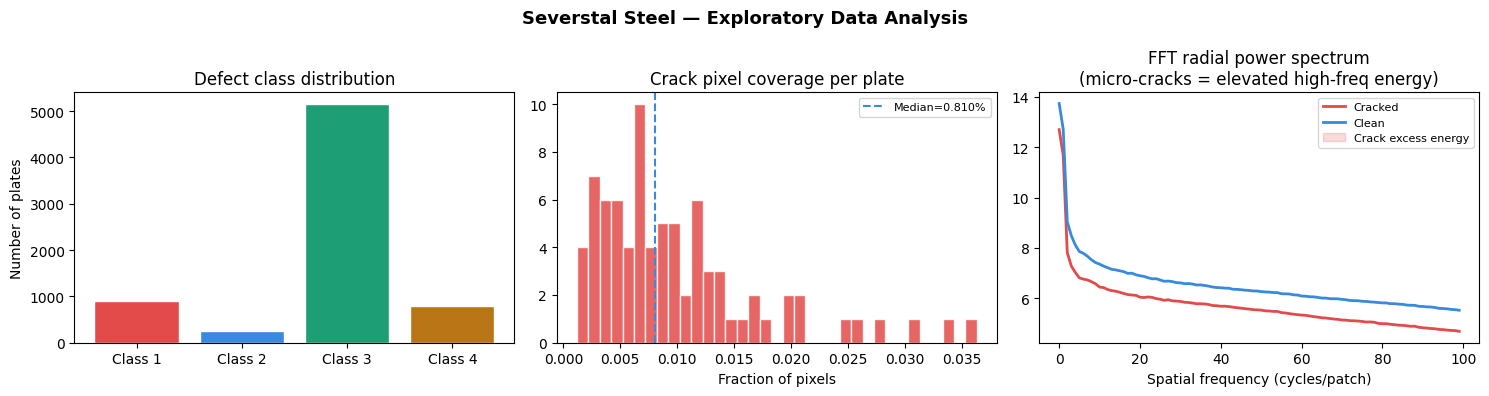

In [ ]:
# ── Cell 4: EDA ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import cv2, numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Severstal Steel — Exploratory Data Analysis", fontsize=13, fontweight="bold")

# ── Plot 1: class distribution ─────────────────────────────────────────────────
class_counts = [df[df["ClassId"]==c]["ImageId"].nunique() for c in [1,2,3,4]]
axes[0].bar([f"Class {i+1}" for i in range(4)], class_counts,
            color=["#E24B4A","#378ADD","#1D9E75","#BA7517"], edgecolor="white")
axes[0].set_title("Defect class distribution")
axes[0].set_ylabel("Number of plates")

# ── Plot 2: crack pixel coverage ───────────────────────────────────────────────
coverages = []
for img_id in list(has_crack)[:80]:
    row = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    if not row.empty and not pd.isna(row.iloc[0]["EncodedPixels"]):
        coverages.append(decode_rle(row.iloc[0]["EncodedPixels"]).mean())

axes[1].hist(coverages, bins=35, color="#E24B4A", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(coverages), color="#378ADD", lw=1.5, linestyle="--",
                label=f"Median={np.median(coverages)*100:.3f}%")
axes[1].set_title("Crack pixel coverage per plate")
axes[1].set_xlabel("Fraction of pixels")
axes[1].legend(fontsize=8)

# ── Plot 3: FFT radial power spectrum ──────────────────────────────────────────
def fft_spectrum(img_gray):
    patch = img_gray[:256, :256].astype(np.float32)
    window = np.outer(np.hanning(256), np.hanning(256))
    f = np.fft.fftshift(np.fft.fft2(patch * window))
    return np.log1p(np.abs(f))

def radial_profile(spec):
    cy, cx = 128, 128
    y, x = np.indices(spec.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tally  = np.bincount(r.ravel(), weights=spec.ravel())
    counts = np.bincount(r.ravel())
    # avoid divide-by-zero for empty bins
    with np.errstate(invalid="ignore"):
        result = np.where(counts > 0, tally / counts, 0.0)
    return result

crack_set = set(has_crack)
crack_rp, clean_rp = [], []

sample_cracked = list(has_crack)[:40]
sample_clean   = [i for i in all_ids if i not in crack_set][:40]

for img_id in sample_cracked + sample_clean:
    img_path = f"{cfg['image_dir']}/{img_id}"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"  Warning: could not load {img_id}, skipping.")
        continue
    if img.shape[0] < 256 or img.shape[1] < 256:
        print(f"  Warning: {img_id} too small ({img.shape}), skipping.")
        continue
    rp = radial_profile(fft_spectrum(img))
    if img_id in crack_set:
        crack_rp.append(rp)
    else:
        clean_rp.append(rp)

print(f"FFT: {len(crack_rp)} cracked, {len(clean_rp)} clean plates processed.")

if len(crack_rp) > 0 and len(clean_rp) > 0:
    # Trim all profiles to the shortest length before averaging
    min_len = min(min(len(r) for r in crack_rp), min(len(r) for r in clean_rp))
    cr = np.mean([r[:min_len] for r in crack_rp], axis=0)[:100]
    cl = np.mean([r[:min_len] for r in clean_rp], axis=0)[:100]
    f  = np.arange(len(cr))

    axes[2].plot(f, cr, color="#E24B4A", lw=2, label="Cracked")
    axes[2].plot(f, cl, color="#378ADD", lw=2, label="Clean")
    axes[2].fill_between(f, cr, cl, where=(cr > cl),
                         alpha=0.2, color="#E24B4A", label="Crack excess energy")
    axes[2].set_title("FFT radial power spectrum\n(micro-cracks = elevated high-freq energy)")
    axes[2].set_xlabel("Spatial frequency (cycles/patch)")
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "Not enough images loaded\nfor FFT analysis",
                 ha="center", va="center", transform=axes[2].transAxes, color="gray")
    print("Could not compute FFT — check that cfg['image_dir'] is correct:",
          cfg["image_dir"])

plt.tight_layout()
plt.savefig("/content/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

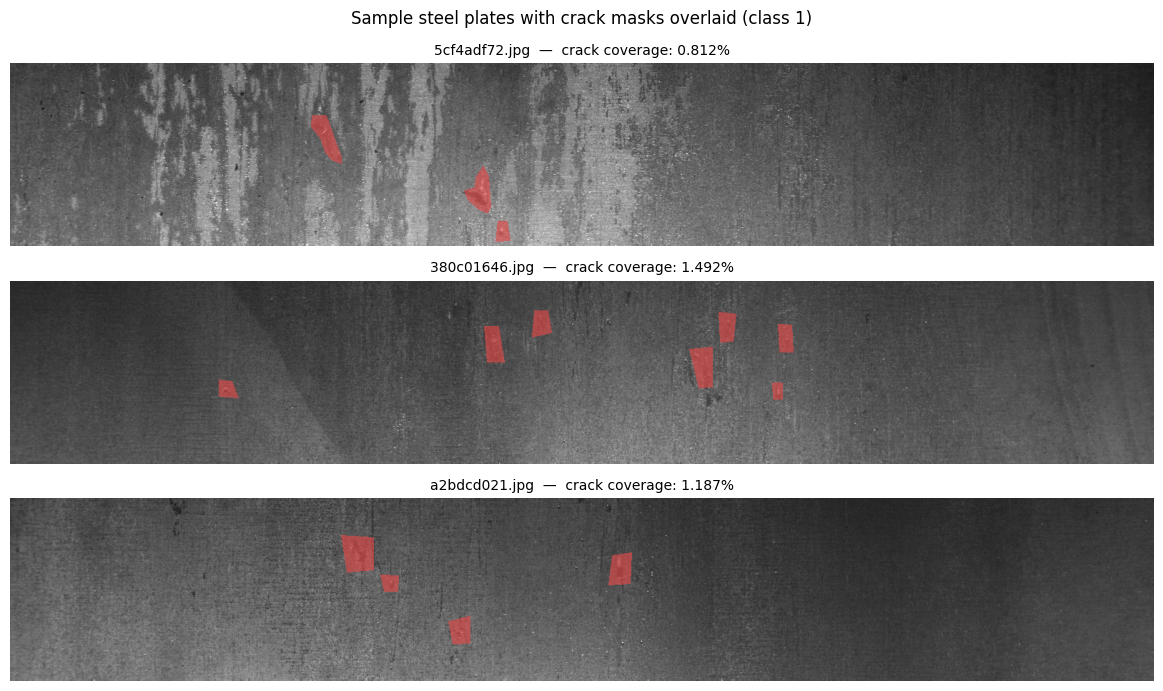

Saved: /content/sample_plates.png


In [ ]:
# ── Cell 5: Visual — sample cracked plates with mask overlay ──────────────────
import matplotlib.pyplot as plt

sample_ids = list(has_crack)[:3]   # convert to list first, then slice

fig, axes  = plt.subplots(3, 1, figsize=(14, 7))
fig.suptitle("Sample steel plates with crack masks overlaid (class 1)", fontsize=12)

for ax, img_id in zip(axes, sample_ids):
    img  = cv2.cvtColor(cv2.imread(f"{cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
    row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    mask = decode_rle(row.iloc[0]["EncodedPixels"] if not row.empty else np.nan)
    overlay = img.astype(float)
    overlay[mask==1] = overlay[mask==1]*0.35 + np.array([226,75,74])*0.65
    ax.imshow(overlay.astype(np.uint8))
    crack_pct = mask.mean()*100
    ax.set_title(f"{img_id}  —  crack coverage: {crack_pct:.3f}%", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/sample_plates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/sample_plates.png")

In [ ]:
# ── Cell 6 (FIXED): Stage 1 — ResNet patch classifier ────────────────────────
import torch, torch.nn as nn, numpy as np, json, time
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── Model ─────────────────────────────────────────────────────────────────────
def build_resnet(backbone="resnet18"):
    model = getattr(models, backbone)(weights="IMAGENET1K_V1")
    # Unfreeze all layers — steel textures differ enough from ImageNet
    for p in model.parameters():
        p.requires_grad_(True)
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 2)
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = build_resnet("resnet18").to(device)

# ── Fix 1: Balanced sampler instead of loss weighting alone ───────────────────
# Count crack vs clean patches in training set
print("Counting patch labels (takes ~2 min)...")
train_ids = json.load(open("/content/split_indices.json"))["train"]
train_ds  = SteelPatchDataset(train_ids, df, cfg, split="train")

labels_list = [train_ds[i][1].item() for i in range(len(train_ds))]
n_crack = sum(labels_list)
n_clean = len(labels_list) - n_crack
print(f"Train patches — Crack: {n_crack} | Clean: {n_clean} | Ratio: {n_clean/max(n_crack,1):.1f}:1")

# Give each crack patch a weight = n_clean/n_crack so they're sampled equally
class_weights = [n_clean / max(n_crack, 1) if l == 1 else 1.0 for l in labels_list]
sampler = WeightedRandomSampler(class_weights, num_samples=len(class_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = build_loaders("val", SteelPatchDataset)

# ── Fix 2: Higher loss weight + focal-style correction ────────────────────────
# Now sampler handles balance, but keep moderate weight as safety net
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0], device=device))

# ── Fix 3: Lower LR, separate param groups ────────────────────────────────────
backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
head_params     = list(model.fc.parameters())

optimizer = AdamW([
    {"params": backbone_params, "lr": 1e-4},   # fine-tune backbone slowly
    {"params": head_params,     "lr": 5e-4},   # train head faster
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Training loop ─────────────────────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n    = len(all_labels)
    f1   = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
    prec = precision_score(all_labels, all_preds, pos_label=1, zero_division=0)
    rec  = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    return total_loss/n, f1, prec, rec

history = {"train_loss":[], "val_loss":[], "val_f1":[]}
best_f1, best_ckpt = 0.0, "/content/best_resnet.pth"
NUM_EPOCHS = 20

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_f1, tr_p, tr_r = run_epoch(train_loader, train=True)
    va_loss, va_f1, va_p, va_r = run_epoch(val_loader,   train=False)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_f1"].append(va_f1)
    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "optimizer": optimizer.state_dict(), "best_val_f1": best_f1, "cfg": cfg,
        }, best_ckpt)
    print(f"Ep {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss {tr_loss:.4f} F1 {tr_f1:.3f} | "
          f"Val loss {va_loss:.4f} F1 {va_f1:.3f} P {va_p:.3f} R {va_r:.3f} | "
          f"{time.time()-t0:.0f}s")

json.dump(history, open("/content/train_history.json","w"))
print(f"\nBest val F1: {best_f1:.4f}  →  {best_ckpt}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


Counting patch labels (takes ~2 min)...
Train patches — Crack: 2246 | Clean: 101440 | Ratio: 45.2:1


In [ ]:
# ── Cell 6b: Save & Load trained model ────────────────────────────────────────
from google.colab import drive
import os, torch, shutil

# Mount drive if not already mounted
drive.mount("/content/drive", force_remount=False)

# ── Save ──────────────────────────────────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/steel_project/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = f"{SAVE_DIR}/resnet18_best.pth"
torch.save({
    "epoch":        NUM_EPOCHS,
    "model_state":  model.state_dict(),
    "optimizer":    optimizer.state_dict(),
    "scheduler":    scheduler.state_dict(),
    "best_val_f1":  best_f1,
    "cfg":          cfg,
}, save_path)

print(f" Checkpoint saved to Google Drive:\n   {save_path}")

# ── How a teammate loads it (paste this at the top of their notebook) ─────────
"""
TEAMMATE LOAD SNIPPET — paste at top of your notebook:

import torch
from torchvision import models
import torch.nn as nn

drive.mount("/content/drive")

CKPT = "/content/drive/MyDrive/steel_project/checkpoints/resnet18_best.pth"
ckpt = torch.load(CKPT, map_location=device)

model = build_resnet("resnet18").to(device)   # same function from Cell 6
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded checkpoint | Best val F1: {ckpt['best_val_f1']:.4f}")
print(f"Config: {ckpt['cfg']}")
"""

In [ ]:
# ── Cell 7: Full evaluation on test set ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

test_loader = build_loaders("test", SteelPatchDataset)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
                             target_names=["Clean","Crack"], digits=4))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {auc:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Clean","Crack"], yticklabels=["Clean","Crack"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix (Test patches)")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, color="#E24B4A", label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend()

# Training curves
axes[2].plot(history["train_loss"], label="Train loss", color="#378ADD")
axes[2].plot(history["val_loss"],   label="Val loss",   color="#E24B4A")
ax2 = axes[2].twinx()
ax2.plot(history["val_f1"], label="Val F1", color="#1D9E75", linestyle="--")
axes[2].set_title("Training Curves")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss"); ax2.set_ylabel("Val F1")
axes[2].legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("/content/evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Save plots to Google Drive ─────────────────────────────────────────────────
import shutil
PLOT_DIR = "/content/drive/MyDrive/steel_project/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

shutil.copy("/content/evaluation_plots.png", f"{PLOT_DIR}/evaluation_plots.png")
print(f" Saved to Drive: {PLOT_DIR}/evaluation_plots.png")

In [ ]:
# ── Cell 8: Plate-level heatmaps from patch predictions ───────────────────────
import torch, numpy as np, cv2, matplotlib.pyplot as plt
from torch.utils.data import DataLoader

model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

def generate_heatmap(image_id, df, cfg, model, device):
    """
    Slide a 256×256 window across a plate with stride=128.
    Accumulate crack probability into a float accumulator, average overlapping regions.
    Returns: (original_image_rgb, heatmap_256x1600 float32)
    """
    ps, st = cfg["patch_size"], cfg["patch_stride"]
    H, W   = cfg["img_h"], cfg["img_w"]
    img    = cv2.cvtColor(cv2.imread(f"{cfg['image_dir']}/{image_id}"),
                          cv2.COLOR_BGR2RGB)
    accum  = np.zeros((H, W), dtype=np.float32)
    count  = np.zeros((H, W), dtype=np.float32)
    tfm    = get_transforms("val")  # no random augment at inference

    patches, coords = [], []
    for r in range(0, H-ps+1, st):
        for c in range(0, W-ps+1, st):
            patch = img[r:r+ps, c:c+ps]
            t     = tfm(image=patch)["image"]  # (3,256,256) float tensor
            patches.append(t)
            coords.append((r, c))

    # Batch inference
    batch_size = 64
    for i in range(0, len(patches), batch_size):
        batch = torch.stack(patches[i:i+batch_size]).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(batch), dim=1)[:,1].cpu().numpy()
        for j, (r, c) in enumerate(coords[i:i+batch_size]):
            accum[r:r+ps, c:c+ps] += probs[j]
            count[r:r+ps, c:c+ps] += 1

    with np.errstate(invalid="ignore"):
        heatmap = np.where(count > 0, accum / count, 0)
    return img, heatmap


# ── Visualise 3 test plates ────────────────────────────────────────────────────
test_ids   = json.load(open("/content/split_indices.json"))["test"]
# Prefer cracked plates for a more interesting demo
cracked_test = [i for i in test_ids if i in has_crack][:3]
sample_ids   = cracked_test if cracked_test else test_ids[:3]

fig, axes = plt.subplots(len(sample_ids), 3,
                          figsize=(18, 4*len(sample_ids)))
fig.suptitle("Plate-Level Crack Probability Heatmaps", fontsize=13, fontweight="bold")

for row_i, img_id in enumerate(sample_ids):
    img, heatmap = generate_heatmap(img_id, df, cfg, model, device)

    # Ground-truth mask
    gt_row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    gt_mask = decode_rle(gt_row.iloc[0]["EncodedPixels"]
                         if not gt_row.empty else np.nan)

    # Original image
    axes[row_i, 0].imshow(img)
    axes[row_i, 0].set_title(f"{img_id}\nOriginal plate")
    axes[row_i, 0].axis("off")

    # Predicted heatmap
    im = axes[row_i, 1].imshow(heatmap, cmap="hot", vmin=0, vmax=1)
    axes[row_i, 1].set_title("Crack probability heatmap")
    axes[row_i, 1].axis("off")
    plt.colorbar(im, ax=axes[row_i, 1], fraction=0.015)

    # Ground truth overlay
    overlay = img.astype(float).copy()
    overlay[gt_mask==1] = overlay[gt_mask==1]*0.35 + np.array([226,75,74])*0.65
    axes[row_i, 2].imshow(overlay.astype(np.uint8))
    axes[row_i, 2].set_title("Ground-truth mask")
    axes[row_i, 2].axis("off")

plt.tight_layout()
plt.savefig("/content/heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/heatmaps.png")